# Proyecto Final: Transformación Digital Empresarial (ISID223)
**Institución:** Escuela Politécnica Nacional (EPN)  
**Facultad:** Ingeniería de Sistemas (FIS)  
**Autores:** 
* Gabriel Quilachamin
* Samuel Lucero  
**Descripción:** Sistema Integrado para una PYME (Red de Farmacias) que comprende el Núcleo Transaccional (Core POS), Módulos de Soporte (ERP, SCM, CRM), Segmentación RFM y Dashboard Gerencial.

In [25]:
import pandas as pd
import numpy as np
import glob
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

print("Librerías cargadas correctamente para el análisis de los 37 archivos de la red de farmacias.")

Librerías cargadas correctamente para el análisis de los 37 archivos de la red de farmacias.


In [26]:

import glob
import pandas as pd

print("Buscando e importando los archivos CSV...")

all_files = glob.glob("*.csv")

if len(all_files) == 0:
    print("¡Alerta! No se encontraron archivos CSV en el directorio actual. Asegúrate de que estén en la misma carpeta que este Notebook.")
else:
    df_list = []
    for f in all_files:
        try:
            temp_df = pd.read_csv(f, low_memory=False)
            df_list.append(temp_df)
        except Exception as e:
            print(f"No se pudo leer el archivo {f}: {e}")
            
    df_master = pd.concat(df_list, ignore_index=True)

    df_master['addeddate'] = pd.to_datetime(df_master['addeddate'], errors='coerce')
    df_master = df_master.dropna(subset=['Invoice', 'addeddate'])

    df_master['unit_price'] = df_master['type'].apply(lambda x: 12.50 if x == 'Drug' else 6.00)
    df_master['total_amount'] = df_master['Sales_pack'].fillna(1) * df_master['unit_price']

    print(f"¡Consolidación exitosa!")
    print(f"Total de archivos leídos: {len(all_files)}")
    print(f"Total de registros procesados en el dataset maestro: {len(df_master):,}")
    display(df_master.head(3))

Buscando e importando los archivos CSV...
¡Consolidación exitosa!
Total de archivos leídos: 37
Total de registros procesados en el dataset maestro: 2,406,006


,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type,unit_price,total_amount
0,1195586,1062,A.M-E.C,gerawa,1.0,1.0,1.0,2024-04-07,2:52PM,Drug,12.5,12.5
1,1195586,1063,R.A-C,gerawa,1.0,1.0,1.0,2024-04-07,2:52PM,Drug,12.5,12.5
2,1195586,8.90425E+12,istovin 20mg,Capsule,3.0,2.0,0.0,2024-04-07,2:51PM,Drug,12.5,0.0


## Fase 2: Desarrollo e Integración de Sistemas (POO y Triggers Automáticos)
En esta sección se implementan las clases del Sistema Principal (Core POS) y los módulos satélites (ERP, SCM y CRM) para asegurar la comunicación automática de datos ante cada transacción registrada.

In [27]:
import datetime


class ModuloSCM:
    def __init__(self):
        self.inventario = {}  
        self.umbral_alerta = 15 

    def actualizar_inventario(self, barcode, cantidad_vendida):
        if barcode not in self.inventario:
            self.inventario[barcode] = 100 
            
        self.inventario[barcode] -= cantidad_vendida
        print(f"[SCM] Stock actualizado para el producto {barcode} | Stock restante: {self.inventario[barcode]}")
        
        
        if self.inventario[barcode] <= self.umbral_alerta:
            self.generar_orden_compra(barcode)
            
    def generar_orden_compra(self, barcode):
        print(f"   -> [SCM ALERTA] Stock crítico detectado. Generando Orden de Compra automática al proveedor para {barcode}.")
        self.inventario[barcode] += 50 


class ModuloERP:
    def __init__(self):
        self.caja_general = 0.0
        self.asientos_contables = []
        
    def registrar_ingreso(self, invoice, monto):
        self.caja_general += monto
        asiento = {
            "fecha": datetime.datetime.now(),
            "factura": invoice,
            "monto_ingreso": monto,
            "tipo": "Ingreso por Venta Farmacéutica"
        }
        self.asientos_contables.append(asiento)
        print(f"[ERP] Asiento contable registrado. Factura: {invoice} | Monto: ${monto:.2f} | Caja Acumulada: ${self.caja_general:.2f}")


class ModuloCRM:
    def __init__(self):
        self.historial_clientes = {} 
        
    def registrar_interaccion(self, cliente_id, fecha_transaccion):
        self.historial_clientes[cliente_id] = fecha_transaccion
        
    def auditar_riesgo_desercion(self, umbral_dias_inactividad=60):
        print("\n[CRM] Ejecutando auditoría automatizada de retención de clientes...")
        hoy = pd.to_datetime('today')
        for cliente, ultima_compra in self.historial_clientes.items():
            dias_inactividad = (hoy - pd.to_datetime(ultima_compra)).days
            if dias_inactividad > umbral_dias_inactividad:
                print(f"   -> [CRM ALERTA] Cliente {cliente} en Riesgo de Deserción. Inactividad: {dias_inactividad} días.")


class CoreBusinessPOS:
    def __init__(self, erp: ModuloERP, scm: ModuloSCM, crm: ModuloCRM):
        self.erp = erp
        self.scm = scm
        self.crm = crm
        self.transacciones_realizadas = []
        
    def registrar_venta(self, invoice, id_cliente, barcode, nombre_producto, cantidad, precio_unitario, fecha_str):
        print(f"\n--- Procesando Transacción (Core POS) ---")
        print(f"Producto: {nombre_producto} | Cantidad: {cantidad} | Factura: {invoice}")
        
        total_venta = cantidad * precio_unitario
        
        self.transacciones_realizadas.append({
            "invoice": invoice,
            "cliente": id_cliente,
            "producto": nombre_producto,
            "total": total_venta,
            "fecha": fecha_str
        })
        
      
        self.scm.actualizar_inventario(barcode, cantidad)
        self.erp.registrar_ingreso(invoice, total_venta)
        self.crm.registrar_interaccion(id_cliente, fecha_str)

print("Clases del sistema principal y módulos de soporte definidas correctamente.")

Clases del sistema principal y módulos de soporte definidas correctamente.


In [28]:

erp_sistema = ModuloERP()
scm_sistema = ModuloSCM()
crm_sistema = ModuloCRM()


pos = CoreBusinessPOS(erp=erp_sistema, scm=scm_sistema, crm=crm_sistema)


muestra_reg = df_master.iloc[0]
pos.registrar_venta(
    invoice=str(muestra_reg['Invoice']),
    id_cliente="CLI-9991",
    barcode=str(muestra_reg['barcode']),
    nombre_producto=str(muestra_reg['name']),
    cantidad=2,
    precio_unitario=15.00,
    fecha_str=str(muestra_reg['addeddate'])
)


--- Procesando Transacción (Core POS) ---
Producto: A.M-E.C | Cantidad: 2 | Factura: 1195586
[SCM] Stock actualizado para el producto 1062 | Stock restante: 98
[ERP] Asiento contable registrado. Factura: 1195586 | Monto: $30.00 | Caja Acumulada: $30.00


## Fase 3: Inteligencia de Negocios - Segmentación RFM
En esta sección se procesa el histórico de transacciones consolidado para calcular el modelo RFM (Recency, Frequency, Monetary), permitiendo clasificar a los clientes en categorías estratégicas como "VIP", "Recuperable" o "Regular".

In [29]:

print("Procesando cálculo RFM optimizado...")


df_master['customer_id'] = "CLI-" + df_master['Invoice'].astype(str).str.slice(-4)

fecha_referencia = df_master['addeddate'].max() + pd.Timedelta(days=1)


rfm_df = df_master.groupby('customer_id').agg({
    'addeddate': lambda x: (fecha_referencia - x.max()).days, 
    'Invoice': 'count',                                       
    'total_amount': 'sum'                                     
}).rename(columns={'addeddate': 'Recency', 'Invoice': 'Frequency', 'total_amount': 'Monetary'})


def safe_qcut(series, labels, ascending=True):
    try:
        return pd.qcut(series, q=len(labels), labels=labels, duplicates='drop')
    except ValueError:
        
        ranks = series.rank(method='first', ascending=ascending)
        return pd.qcut(ranks, q=len(labels), labels=labels, duplicates='drop')


rfm_df['R'] = safe_qcut(rfm_df['Recency'], labels=[4, 3, 2, 1], ascending=False)
rfm_df['F'] = safe_qcut(rfm_df['Frequency'], labels=[1, 2, 3, 4], ascending=True)
rfm_df['M'] = safe_qcut(rfm_df['Monetary'], labels=[1, 2, 3, 4], ascending=True)


rfm_df['RFM_Score'] = rfm_df['R'].astype(str) + rfm_df['F'].astype(str) + rfm_df['M'].astype(str)


def asignar_segmento(row):
    
    if row['Monetary'] >= rfm_df['Monetary'].median() and row['Frequency'] >= rfm_df['Frequency'].median():
        return 'VIP'
    elif row['Recency'] > rfm_df['Recency'].median() and row['Frequency'] >= 2:
        return 'Recuperable'
    else:
        return 'Regular'

rfm_df['Segmento'] = rfm_df.apply(asignar_segmento, axis=1)

print("¡Segmentación RFM completada con éxito sin errores de bines!")
display(rfm_df.head(5))
print("\nDistribución de Clientes por Segmento:")
print(rfm_df['Segmento'].value_counts())

Procesando cálculo RFM optimizado...
¡Segmentación RFM completada con éxito sin errores de bines!


,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segmento
customer_id,,,,,,,,
CLI-0000,6,225,2374.0,4,2,1,421,Recuperable
CLI-0001,8,277,3403.0,4,4,4,444,VIP
CLI-0002,10,250,2785.0,4,4,3,443,VIP
CLI-0003,5,214,2399.5,4,1,1,411,Recuperable
CLI-0004,4,225,2409.0,3,2,1,321,Recuperable



Distribución de Clientes por Segmento:
Segmento
Regular        4382
VIP            4137
Recuperable    2443
Name: count, dtype: int64


## Fase 4: Visualización y Control (Dashboard Gerencial)
En esta sección se genera un Tablero de Control gráfico conectado a los datos procesados, mostrando la evolución temporal de las operaciones, la segmentación RFM de los clientes y los indicadores clave de rendimiento (KPIs).

Generando el Dashboard Gerencial...


C:\Users\user\AppData\Local\Temp\ipykernel_10416\4255207733.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, x='type', ax=axes[1, 0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_10416\4255207733.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_prods, x='count', y='name', ax=axes[1, 1], palette='Blues_r')


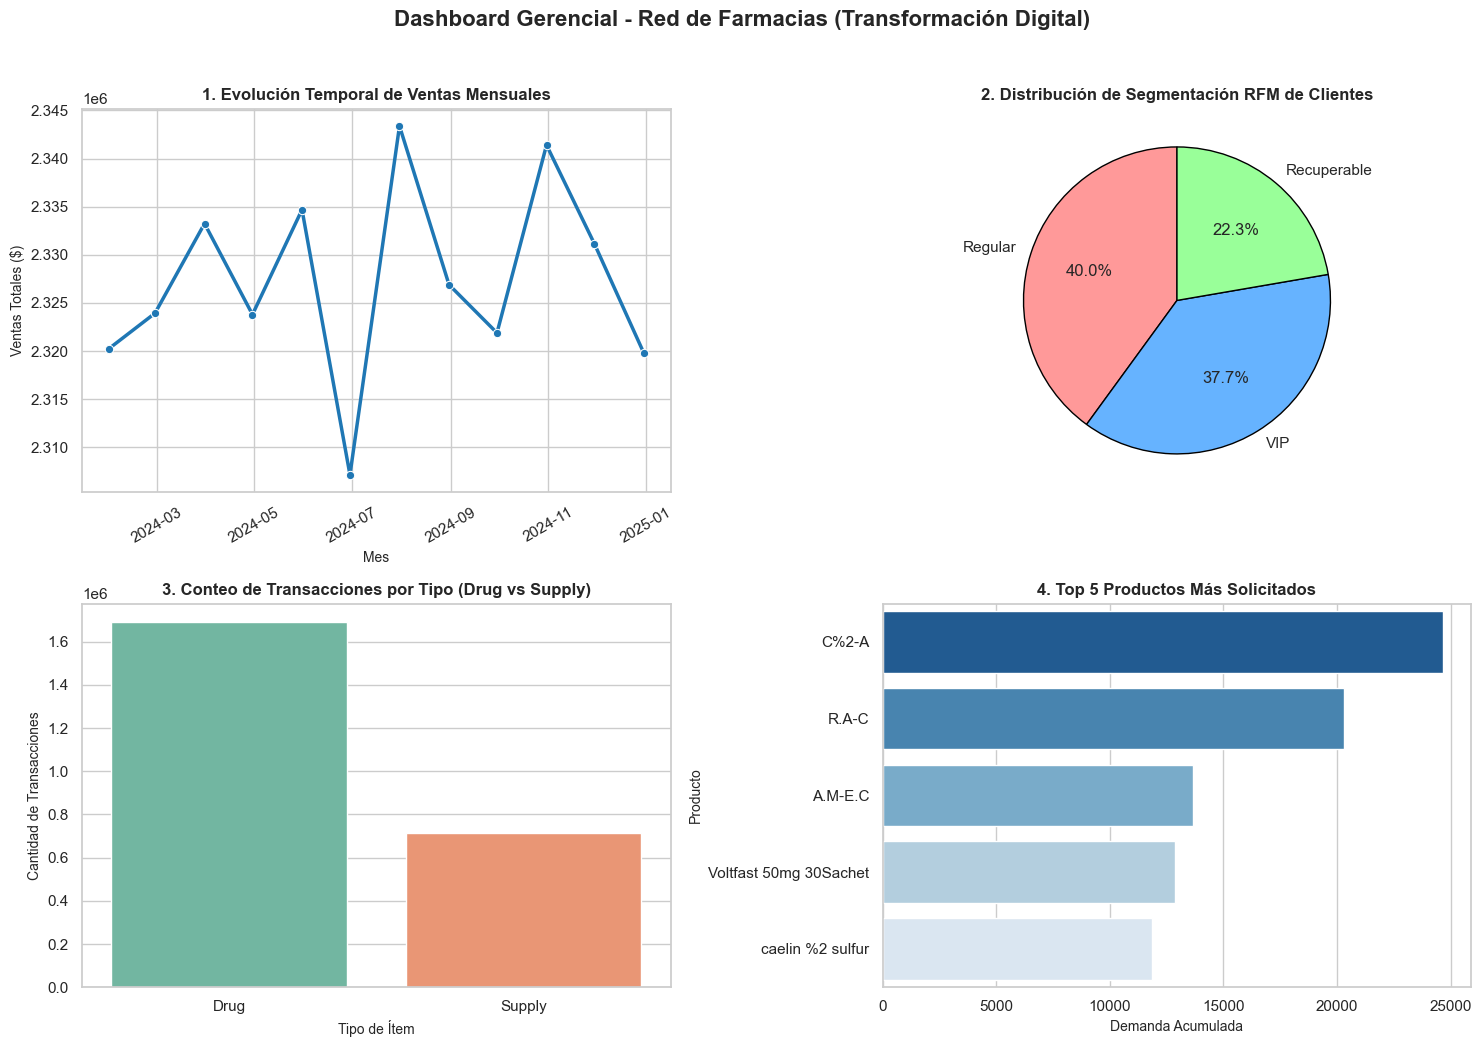

¡Dashboard gerencial generado y guardado exitosamente como 'dashboard_gerencial.png'!


In [30]:

import matplotlib.pyplot as plt
import seaborn as sns

print("Generando el Dashboard Gerencial...")


fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Dashboard Gerencial - Red de Farmacias (Transformación Digital)', fontsize=16, fontweight='bold', y=0.95)


df_temp = df_master.set_index('addeddate').resample('ME')['total_amount'].sum().reset_index()
sns.lineplot(data=df_temp, x='addeddate', y='total_amount', ax=axes[0, 0], marker='o', color='#1f77b4', linewidth=2.5)
axes[0, 0].set_title('1. Evolución Temporal de Ventas Mensuales', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Mes', fontsize=10)
axes[0, 0].set_ylabel('Ventas Totales ($)', fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=30)


segment_counts = rfm_df['Segmento'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99']
axes[0, 1].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[0, 1].set_title('2. Distribución de Segmentación RFM de Clientes', fontsize=12, fontweight='bold')


sns.countplot(data=df_master, x='type', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Conteo de Transacciones por Tipo (Drug vs Supply)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tipo de Ítem', fontsize=10)
axes[1, 0].set_ylabel('Cantidad de Transacciones', fontsize=10)


top_prods = df_master['name'].value_counts().head(5).reset_index()
top_prods.columns = ['name', 'count']
sns.barplot(data=top_prods, x='count', y='name', ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title('4. Top 5 Productos Más Solicitados', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Demanda Acumulada', fontsize=10)
axes[1, 1].set_ylabel('Producto', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])


plt.savefig('dashboard_gerencial.png', dpi=300)
plt.show()

print("¡Dashboard gerencial generado y guardado exitosamente como 'dashboard_gerencial.png'!")